# L16 · Matrix Factorization and NMF

*Companion notebook for Lecture 16 — Matrix Factorization and NMF (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Implement the Lee–Seung multiplicative updates for NMF from scratch, redo the worked example, and check them against scikit-learn.
2. Find gene expression programs in single cells (PBMC3k) with NMF: top genes per program and program usage per cell type.
3. Choose the number of programs $k$ with reconstruction error and stability across random restarts.
4. Compare PCA directions and NMF programs on the same data (signs, sparsity, interpretability).
5. Fill in missing entries of an expression matrix with a low-rank model (alternating least squares and SGD with biases).
6. (CS284A) Fit NMF with the KL / Poisson loss to counts; recover planted mutational signatures from simulated catalogs.

Notation (as on the slides): $n$ samples (cells, tumors), $d$ genes, $\mathbf X\in\mathbb R_{\ge 0}^{n\times d}$ with samples in rows,
$\mathbf X \approx \mathbf W\mathbf H$ with $\mathbf W\in\mathbb R_{\ge0}^{n\times k}$ (**usage** of each program by each sample) and
$\mathbf H\in\mathbb R_{\ge0}^{k\times d}$ (**programs**: one row per program, one weight per gene). $\Omega$ is the set of observed entries.

**Runtime.** About 3–5 minutes on a 4-thread laptop CPU; no GPU needed. To stay within that budget, the $k$ sweep in
Section 4 uses 3 restarts per $k$ instead of the lecture's 10 (the numbers quoted on the slides for $k = 10$ are reproduced exactly).

In [1]:
import os
# numba (used by Scanpy's neighbor search / UMAP) and PyTorch (imported by course_utils) ship different OpenMP
# runtimes; on macOS the combination can crash the kernel. The 'workqueue' threading layer avoids the conflict.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import NMF
from sklearn.exceptions import ConvergenceWarning
from course_utils import seed_everything, plot_style, DATA, load_tcga, PALETTE

# scikit-learn warns when NMF stops at max_iter (we cap iterations on purpose, as in the lecture)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="zero-centering a sparse")   # Scanpy note when scaling a sparse copy
rng = seed_everything(0)
plot_style()
T0 = time.time()

## 1. Model: NMF with multiplicative updates, from scratch

Objective (Frobenius): $\min_{\mathbf W\ge0,\ \mathbf H\ge0}\ J = \|\mathbf X-\mathbf W\mathbf H\|_F^2$.
Lee & Seung (2001) showed that the following element-wise updates never increase $J$
($\odot$ and the fraction bar are element-wise):

$$\mathbf H \leftarrow \mathbf H \odot \frac{\mathbf W^\top\mathbf X}{\mathbf W^\top\mathbf W\mathbf H},\qquad
  \mathbf W \leftarrow \mathbf W \odot \frac{\mathbf X\mathbf H^\top}{\mathbf W\mathbf H\mathbf H^\top}.$$

Every factor is multiplied by a nonnegative ratio, so nonnegative starting values stay nonnegative — no projection step is needed.
First, the worked example from the slides (4 cells × 3 genes, $k=2$; the slides update $\mathbf H$ first, then $\mathbf W$).

In [2]:
def mu_step_H(X, W, H, eps=1e-12):
    return H * (W.T @ X) / (W.T @ W @ H + eps)

def mu_step_W(X, W, H, eps=1e-12):
    return W * (X @ H.T) / (W @ H @ H.T + eps)

def loss(X, W, H):
    return float(((X - W @ H) ** 2).sum())

Xs = np.array([[3, 1, 0], [2, 1, 1], [0, 1, 3], [1, 2, 2]], float)
W = np.array([[1, 0.5], [1, 0.5], [1, 1.0], [1, 1.0]])
H = np.array([[1.0, 1.0, 1.0], [1.0, 0.5, 1.0]])
print("W^T X =\n", W.T @ Xs, "\nW^T W H =\n", W.T @ W @ H)
print(f"initial loss    {loss(Xs, W, H):.3f}")
H = mu_step_H(Xs, W, H)
print(f"after H update  {loss(Xs, W, H):.3f}   H_new =\n", np.round(H, 2))
W = mu_step_W(Xs, W, H)
print(f"after W update  {loss(Xs, W, H):.3f}   W_new =\n", np.round(W, 2))
hist_toy = []
for _ in range(200):
    H = mu_step_H(Xs, W, H); W = mu_step_W(Xs, W, H)
    hist_toy.append(loss(Xs, W, H))
print(f"after 200 more iterations {hist_toy[-1]:.3f}; loss never increased: {bool(np.all(np.diff(hist_toy) <= 1e-12))}")
print("reconstruction W H:\n", np.round(W @ H, 2))

W^T X =
 [[6.  5.  6. ]
 [3.5 4.  5.5]] 
W^T W H =
 [[7.   5.5  7.  ]
 [5.5  4.25 5.5 ]]
initial loss    11.625
after H update  10.350   H_new =
 [[0.86 0.91 0.86]
 [0.64 0.47 1.  ]]
after W update  10.086   W_new =
 [[1.08 0.45]
 [1.08 0.52]
 [0.84 1.  ]
 [1.06 1.03]]
after 200 more iterations 0.531; loss never increased: True
reconstruction W H:
 [[2.96 1.1  0.  ]
 [1.94 1.16 0.93]
 [0.   1.34 2.84]
 [1.19 1.5  2.24]]


**Check against scikit-learn.** `NMF(solver="mu")` implements the same updates for `beta_loss="frobenius"`
(it updates $\mathbf W$ first, then $\mathbf H$, and has small safeguards against division by zero).
We start both from the same random $\mathbf W_0, \mathbf H_0$ on a random nonnegative matrix and compare.

In [3]:
def nmf_mu(X, k, iters=200, seed=0):
    r = np.random.default_rng(seed)
    scale = np.sqrt(X.mean() / k)
    W = r.uniform(0, 1, (X.shape[0], k)) * scale
    H = r.uniform(0, 1, (k, X.shape[1])) * scale
    W0, H0, hist = W.copy(), H.copy(), []
    for _ in range(iters):
        W = mu_step_W(X, W, H)      # W first, as in scikit-learn
        H = mu_step_H(X, W, H)
        hist.append(loss(X, W, H))
    return W, H, W0, H0, hist

Xr = rng.gamma(1.0, 1.0, (60, 40)) @ rng.gamma(1.0, 1.0, (40, 30)) / 10
Wm, Hm, W0, H0, hist = nmf_mu(Xr, 5, iters=200)
sk = NMF(5, init="custom", solver="mu", max_iter=200, tol=0).fit(Xr, W=W0.copy(), H=H0.copy())
print(f"from scratch: loss after 200 iterations = {hist[-1]:.6f}")
print(f"scikit-learn: loss after 200 iterations = {sk.reconstruction_err_ ** 2:.6f}   (reconstruction_err_ is the Frobenius norm)")
print("max |H difference|:", np.abs(sk.components_ - Hm).max())
print("loss never increased:", bool(np.all(np.diff(hist) <= 1e-9 * hist[0])))

from scratch: loss after 200 iterations = 388.300387
scikit-learn: loss after 200 iterations = 388.300387   (reconstruction_err_ is the Frobenius norm)
max |H difference|: 3.9395153805799055e-12
loss never increased: True


## 2. Dataset: PBMC3k single-cell RNA-seq

**What is measured.** Droplet single-cell RNA-seq (10x Genomics) of peripheral blood mononuclear cells from one healthy
donor: for every cell, the number of RNA molecules (UMIs) detected per gene. **One sample = one cell.**

**Input to NMF:** log-normalized expression ($\log(1 + 10^4\cdot$ counts / cell total$)$) of the highly variable genes —
nonnegative, as NMF requires. We do **not** center or z-score (that would create negative values).
**Target:** none — NMF is unsupervised. The cell-type labels come from the L14/L15 pipeline (Leiden clusters annotated with
marker genes) and are used only to *interpret* the programs. **Why it matters:** programs reveal both cell identity and
activities shared across cell types (antigen presentation, cytotoxicity, …).

Source: 10x Genomics public data set "3k PBMCs from a healthy donor" (Zheng et al., *Nat. Commun.* 2017; 10x Genomics
datasets are released under CC BY 4.0), loaded with `scanpy.datasets.pbmc3k()` and cached in `applications/data/`.
Preprocessing follows the Scanpy PBMC3k tutorial (Wolf et al., *Genome Biology* 2018), identical to L15.

In [4]:
import scanpy as sc
sc.settings.datasetdir = DATA
sc.settings.verbosity = 0
adata = sc.datasets.pbmc3k()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[(adata.obs.n_genes_by_counts < 2500) & (adata.obs.pct_counts_mt < 5)].copy()
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
hv = adata[:, adata.var.highly_variable].copy()
X = np.asarray(hv.X.todense(), dtype=np.float64)
genes = np.array(hv.var_names)
n, d = X.shape
print(f"{n} cells x {d} highly variable genes; min {X.min():.1f}, max {X.max():.2f}; {100 * (X == 0).mean():.0f}% zeros")

2638 cells x 1838 highly variable genes; min 0.0, max 7.15; 92% zeros


**Exploration / preprocessing for the labels.** Cell types as in L15: scale, PCA, kNN graph, Leiden clusters, then
label each cluster with the canonical marker set of the Scanpy tutorial with the highest (z-scored) mean expression.
The scaled copy is used *only* for the labels and the UMAP; NMF gets the unscaled, nonnegative matrix `X`.

In [5]:
MARKERS = {"CD4 T": ["IL7R", "CCR7"], "CD8 T": ["CD8A", "CD8B"], "NK": ["GNLY", "NKG7"], "B": ["MS4A1", "CD79A"],
           "CD14 mono": ["CD14", "LYZ"], "FCGR3A mono": ["FCGR3A", "MS4A7"], "DC": ["FCER1A", "CST3"], "Platelet": ["PPBP"]}
CTYPES = list(MARKERS)
tmp = hv.copy()
sc.pp.scale(tmp, max_value=10)
sc.tl.pca(tmp, n_comps=50, svd_solver="arpack", random_state=0)
sc.pp.neighbors(tmp, n_neighbors=10, n_pcs=40, random_state=0)
sc.tl.leiden(tmp, resolution=1.0, random_state=0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(tmp, random_state=0)
R = adata.raw.to_adata()
M = pd.DataFrame({ct: np.asarray(R[:, gs].X.todense()).mean(1) for ct, gs in MARKERS.items()})
M["cl"] = tmp.obs.leiden.values
G = M.groupby("cl", observed=True).mean()
mapping = ((G - G.mean()) / G.std()).idxmax(axis=1).to_dict()
ctype = tmp.obs.leiden.map(mapping).astype(str).values
umap = tmp.obsm["X_umap"]
print(pd.Series(ctype).value_counts().to_dict())

{'CD4 T': 1173, 'CD14 mono': 427, 'B': 339, 'CD8 T': 275, 'FCGR3A mono': 211, 'NK': 163, 'DC': 37, 'Platelet': 13}


## 3. Training: NMF on PBMC3k with $k = 10$ programs, 10 random restarts

As in the lecture: scikit-learn's coordinate-descent solver (much faster than multiplicative updates on this size),
random initialization, at most 500 iterations, seeds 0–9; we keep the restart with the lowest error. For speed the NMF fits
run in float32 (about 2× faster than float64; errors agree to 4 decimals and the programs' top genes are identical). Then we fix the
**scaling ambiguity** ($\mathbf W\mathbf H = (\mathbf W\mathbf D)(\mathbf D^{-1}\mathbf H)$ for any positive diagonal $\mathbf D$):
each program (row of $\mathbf H$) is rescaled to sum to 1 and $\mathbf W$ absorbs the scale.

In [6]:
K, N_RESTART = 10, 10
X32 = X.astype(np.float32)       # NMF input (float32 for speed)
normX = np.linalg.norm(X)
t = time.time()
fits = []
for r in range(N_RESTART):
    m = NMF(K, init="random", solver="cd", max_iter=500, tol=1e-4, random_state=r)
    Wr = m.fit_transform(X32).astype(np.float64)
    fits.append((m.reconstruction_err_ / normX, Wr, m.components_.astype(np.float64)))
rel_errs = np.array([f[0] for f in fits])
best = int(rel_errs.argmin())
_, W, H = fits[best]
s = H.sum(1)
H, W = H / s[:, None], W * s[None, :]
sv = np.linalg.svd(X, compute_uv=False)                       # singular values of the uncentered X
svd_bound = lambda k: np.sqrt((sv[k:] ** 2).sum()) / normX    # Eckart–Young: best possible rank-k error
print(f"{N_RESTART} restarts in {time.time() - t:.0f} s")
print(f"relative error ||X - WH||_F / ||X||_F: mean over restarts {rel_errs.mean():.3f} "
      f"(range {rel_errs.min():.4f}-{rel_errs.max():.4f}); best restart = seed {best}")
print(f"truncated-SVD bound at k = {K}: {svd_bound(K):.3f}")

10 restarts in 59 s
relative error ||X - WH||_F / ||X||_F: mean over restarts 0.782 (range 0.7816-0.7818); best restart = seed 4
truncated-SVD bound at k = 10: 0.780


**Evaluation: top genes per program.** Programs are named P1…P10 after sorting them by the cell type that uses them
most (the numbering of an NMF fit itself means nothing). Usage fraction = a cell's row of $\mathbf W$ divided by its sum.

In [7]:
frac = W / W.sum(1, keepdims=True)     # usage fractions: each cell's program usage sums to 1
mean_use = pd.DataFrame([[frac[ctype == c, l].mean() for l in range(K)] for c in CTYPES], index=CTYPES)
order = sorted(range(K), key=lambda l: (mean_use[l].values.argmax(), -mean_use[l].max()))
names = {l: f"P{i + 1}" for i, l in enumerate(order)}
tops = {l: genes[np.argsort(-H[l])[:10]] for l in range(K)}
TUT = {"IL7R", "CCR7", "S100A4", "CD14", "LYZ", "LGALS3", "S100A8", "MS4A1", "CD79A", "CD8A", "CD8B", "GNLY", "NKG7",
       "KLRB1", "FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"}
rows = []
for l in order:
    rows.append(dict(program=names[l], most_used_by=mean_use[l].idxmax(), usage=round(mean_use[l].max(), 2),
                     top_genes=", ".join(tops[l]), tutorial_markers=", ".join(g for g in tops[l] if g in TUT)))
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
print(pd.DataFrame(rows).to_string(index=False))
print("tutorial markers that are not among the highly variable genes:", sorted(TUT - set(genes)))

program most_used_by  usage                                                                              top_genes tutorial_markers
     P1        CD4 T   0.42                     LTB, IL32, PTPRCAP, S100A6, GIMAP7, UBB, CYBA, CD2, ARPC1B, GIMAP4                 
     P2        CD4 T   0.19                 HINT1, HSP90AA1, PSME1, SRSF3, YWHAB, RBM3, PSMA7, PSMB8, EIF3D, GTF3A                 
     P3        CD4 T   0.19                   SELL, SRSF5, PNRC1, LIMD2, RBM3, CD48, TRAF3IP3, UBXN1, ATP5O, SMDT1                 
     P4        CD8 T   0.31                          CCL5, NKG7, IL32, GZMA, GZMK, CTSW, CST7, PTPRCAP, LYAR, CYBA             NKG7
     P5           NK   0.58                            GNLY, NKG7, GZMB, PRF1, FGFBP2, CST7, CTSW, GZMA, UBB, CYBA       GNLY, NKG7
     P6            B   0.56       HLA-DPB1, HLA-DRB1, CD37, HLA-DPA1, CD79A, LTB, CD79B, HLA-DQA1, HLA-DQB1, MS4A1     CD79A, MS4A1
     P7    CD14 mono   0.49                     S100A8, TYROBP, S100A6, CST3

Tutorial marker genes (Scanpy PBMC3k) appear among the top genes of the programs used by the
matching cell types, e.g. GNLY/NKG7 in the NK program, CD79A in the B-cell program, S100A8 and CST3 in the myeloid
programs, PPBP in the platelet program — without NMF ever seeing the labels. Some programs are *shared* (e.g., an
MHC class II / HLA program used by DCs, monocytes and B cells) and one or two look like broadly expressed
"housekeeping" programs. That is typical: NMF programs are gene modules, not necessarily cell types.

## 4. Visualization: program usage per cell type

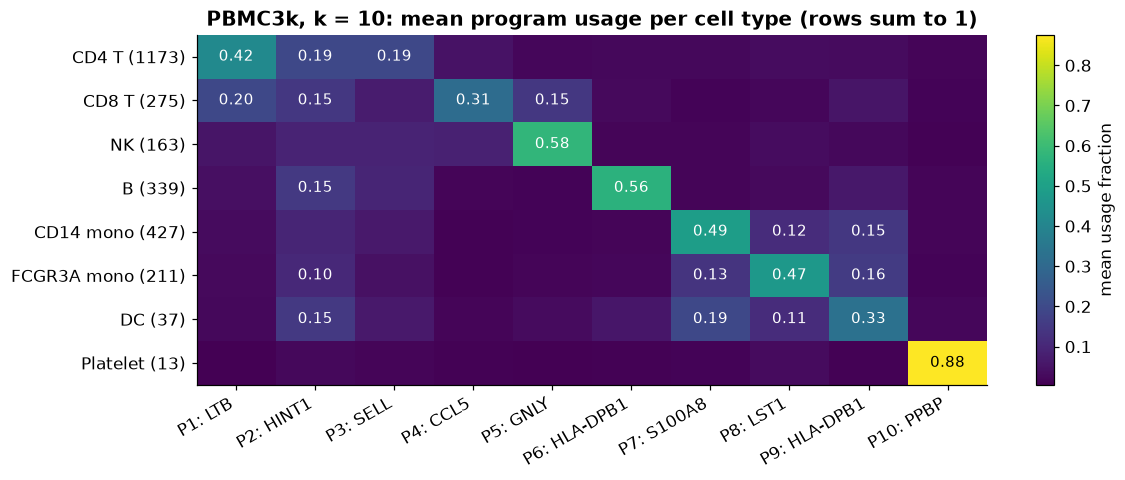

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
Mu = mean_use[order].values
im = ax.imshow(Mu, cmap="viridis", aspect="auto")
ax.set_yticks(range(len(CTYPES)), [f"{c} ({(ctype == c).sum()})" for c in CTYPES])
ax.set_xticks(range(K), [f"{names[l]}: {tops[l][0]}" for l in order], rotation=30, ha="right")
for i in range(Mu.shape[0]):
    for j in range(K):
        if Mu[i, j] >= 0.1:
            ax.text(j, i, f"{Mu[i, j]:.2f}", ha="center", va="center", color="w" if Mu[i, j] < 0.6 else "k", fontsize=10)
plt.colorbar(im, label="mean usage fraction")
ax.set_title("PBMC3k, k = 10: mean program usage per cell type (rows sum to 1)")
plt.tight_layout(); plt.show()

Cells use **several** programs at once: the usage of a program is a continuous amount, not a cluster label.
Below: the NK program, the shared HLA class II program and the CD14-monocyte program on the L15 UMAP (as on the slide).

median usage of each cell's dominant program: 0.45; cells whose dominant program has < 50% of the usage: 63%


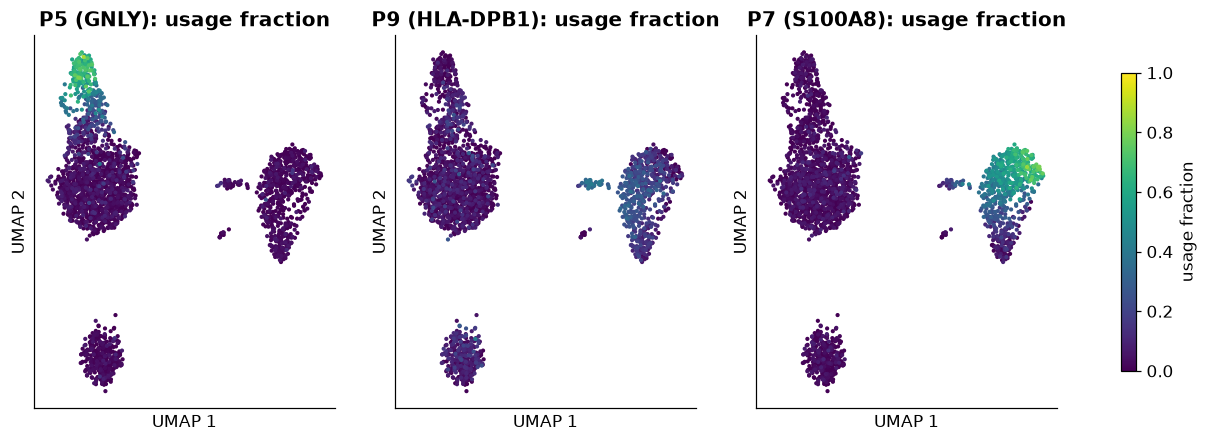

In [9]:
top1 = np.sort(frac, 1)[:, -1]
print(f"median usage of each cell's dominant program: {np.median(top1):.2f}; "
      f"cells whose dominant program has < 50% of the usage: {100 * (top1 < 0.5).mean():.0f}%")
gidx = {g: i for i, g in enumerate(genes)}
find = lambda gene: int(np.argmax(H[:, gidx[gene]]))            # program with the largest weight on a marker gene
l_nk, l_mono = find("GNLY"), find("S100A8")
hla = [l for l in order if tops[l][0].startswith("HLA") and "CD79A" not in tops[l]]   # HLA class II, not the B-cell one
l_hla = hla[0] if hla else find("HLA-DMA")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, l in zip(axes, (l_nk, l_hla, l_mono)):
    o = np.argsort(frac[:, l])
    sca = ax.scatter(umap[o, 0], umap[o, 1], c=frac[o, l], s=3, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{names[l]} ({tops[l][0]}): usage fraction"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.colorbar(sca, ax=axes, shrink=0.8, label="usage fraction")
plt.show()

## 5. Choosing $k$: reconstruction error and stability across restarts

The error always decreases with $k$ (more parameters), so it cannot choose $k$ by itself. **Stability** asks whether
independent random restarts find the *same* programs: match the programs of two runs one-to-one (Hungarian algorithm on
the cosine similarity of rows of $\mathbf H$) and average the matched similarities. The truncated SVD error is a lower bound
for any rank-$k$ factorization (Eckart–Young), nonnegative or not.

First $k = 10$, using the 10 restarts of Section 3 (these are the numbers on the slides).

k = 10: stability (mean matched cosine over 45 restart pairs) 0.93, worst pair 0.86


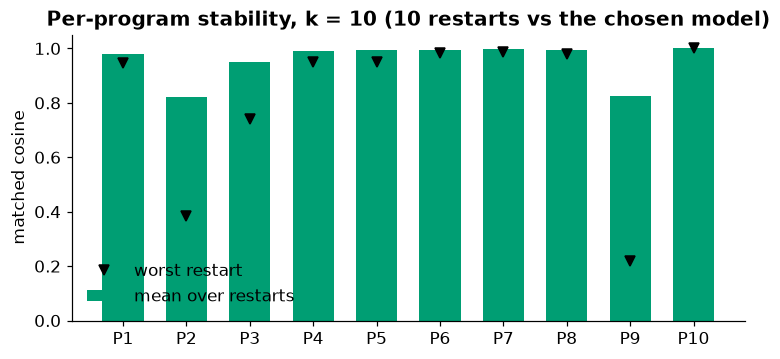

per-program mean matched cosine 0.82-1.00; worst restart for the least stable program 0.22


In [10]:
def matched_cos(Ha, Hb):
    A = Ha / np.linalg.norm(Ha, axis=1, keepdims=True)
    B = Hb / np.linalg.norm(Hb, axis=1, keepdims=True)
    C = A @ B.T
    r, c = linear_sum_assignment(-C)
    return C[r, c]

Hs10 = [f[2] for f in fits]
pairs10 = [matched_cos(Hs10[i], Hs10[j]).mean() for i in range(N_RESTART) for j in range(i + 1, N_RESTART)]
print(f"k = {K}: stability (mean matched cosine over {len(pairs10)} restart pairs) {np.mean(pairs10):.2f}, worst pair {np.min(pairs10):.2f}")
# per program: match every restart to the chosen model (rows of H stay in the chosen model's order)
per_prog = np.array([matched_cos(H, Hr) for Hr in Hs10])      # restarts x programs
fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(K)
ax.bar(x, per_prog[:, order].mean(0), color=PALETTE[2], width=0.65, label="mean over restarts")
ax.plot(x, per_prog[:, order].min(0), "v", color="k", ms=7, label="worst restart")
ax.set_xticks(x, [names[l] for l in order]); ax.set_ylim(0, 1.05); ax.set_ylabel("matched cosine")
ax.set_title(f"Per-program stability, k = {K} ({N_RESTART} restarts vs the chosen model)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
print(f"per-program mean matched cosine {per_prog.mean(0).min():.2f}-{per_prog.mean(0).max():.2f}; "
      f"worst restart for the least stable program {per_prog.min():.2f}")

Now a sweep over $k$. The lecture used $k = 2,\dots,16$ with 10 restarts each (150 fits, ≈ 15–25 min on a laptop CPU).
Here we use **3 restarts** per $k$ and every third $k$ to keep the notebook fast (for $k = 10$ we reuse the first 3
restarts of Section 3, so all points of the curve use the same number of restarts). The mean error hardly depends on the
number of restarts; stability from 3 restarts (3 pairs) is noisier than from 10 (45 pairs). Set `KS_SWEEP = range(2, 17)`
and `N_SWEEP = 10` to reproduce the slide figure exactly.

k sweep (6 values of k x 3 restarts): 32 s


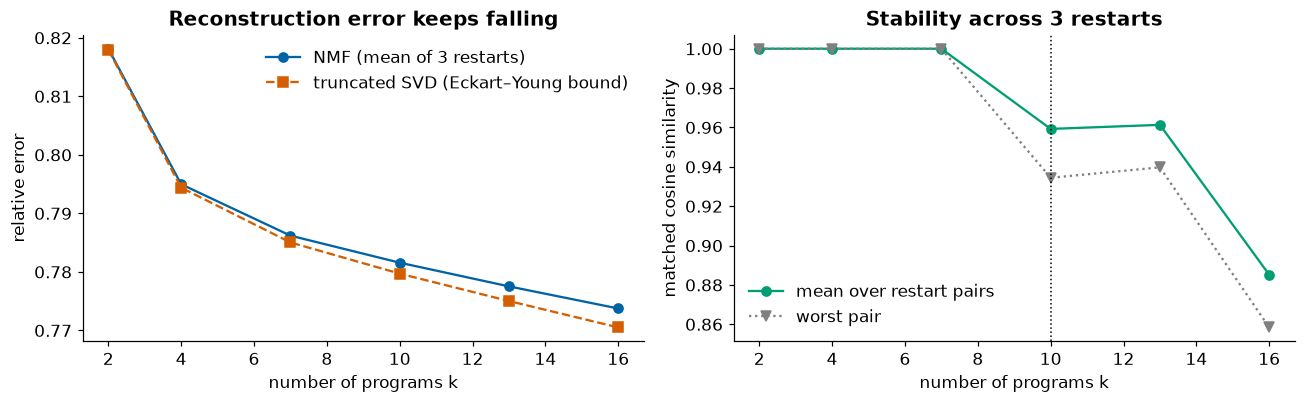

 k  nmf_error  svd_error  stability  worst_pair
 2     0.8181     0.8179      1.000       1.000
 4     0.7950     0.7944      1.000       1.000
 7     0.7862     0.7850      1.000       1.000
10     0.7816     0.7797      0.959       0.934
13     0.7775     0.7750      0.961       0.940
16     0.7737     0.7705      0.885       0.858


In [11]:
KS_SWEEP, N_SWEEP = [2, 4, 7, 10, 13, 16], 3
t = time.time()
errs, stabs, stab_min = [], [], []
for k in KS_SWEEP:
    if k == K:
        Hs, es = Hs10[:N_SWEEP], list(rel_errs[:N_SWEEP])
    else:
        Hs, es = [], []
        for r in range(N_SWEEP):
            m = NMF(k, init="random", solver="cd", max_iter=500, tol=1e-4, random_state=r).fit(X32)
            Hs.append(m.components_.astype(np.float64)); es.append(m.reconstruction_err_ / normX)
    sims = [matched_cos(Hs[i], Hs[j]).mean() for i in range(N_SWEEP) for j in range(i + 1, N_SWEEP)]
    errs.append(np.mean(es)); stabs.append(np.mean(sims)); stab_min.append(np.min(sims))
print(f"k sweep ({len(KS_SWEEP)} values of k x {N_SWEEP} restarts): {time.time() - t:.0f} s")
svd_err = [svd_bound(k) for k in KS_SWEEP]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(KS_SWEEP, errs, "o-", color=PALETTE[0], label=f"NMF (mean of {N_SWEEP} restarts)")
axes[0].plot(KS_SWEEP, svd_err, "s--", color=PALETTE[5], label="truncated SVD (Eckart–Young bound)")
axes[0].set(xlabel="number of programs k", ylabel="relative error", title="Reconstruction error keeps falling"); axes[0].legend()
axes[1].plot(KS_SWEEP, stabs, "o-", color=PALETTE[2], label="mean over restart pairs")
axes[1].plot(KS_SWEEP, stab_min, "v:", color="gray", label="worst pair")
axes[1].axvline(K, color="k", ls=":", lw=1)
axes[1].set(xlabel="number of programs k", ylabel="matched cosine similarity", title=f"Stability across {N_SWEEP} restarts")
axes[1].legend(loc="lower left")
plt.tight_layout(); plt.show()
print(pd.DataFrame(dict(k=KS_SWEEP, nmf_error=np.round(errs, 4), svd_error=np.round(svd_err, 4),
                        stability=np.round(stabs, 3), worst_pair=np.round(stab_min, 3))).to_string(index=False))

Single-cell data are noisy, so even many programs leave most of the Frobenius norm unexplained (the error curve is
flat and stays just above the SVD bound); the stability curve shows which $k$ give reproducible programs (small $k$ are
trivially stable). Consensus NMF (cNMF, Kotliar et al., *eLife* 2019) makes this systematic: many restarts → cluster the
programs → keep the consensus, and pick $k$ trading stability against error.

## 6. PCA vs NMF on the same cells

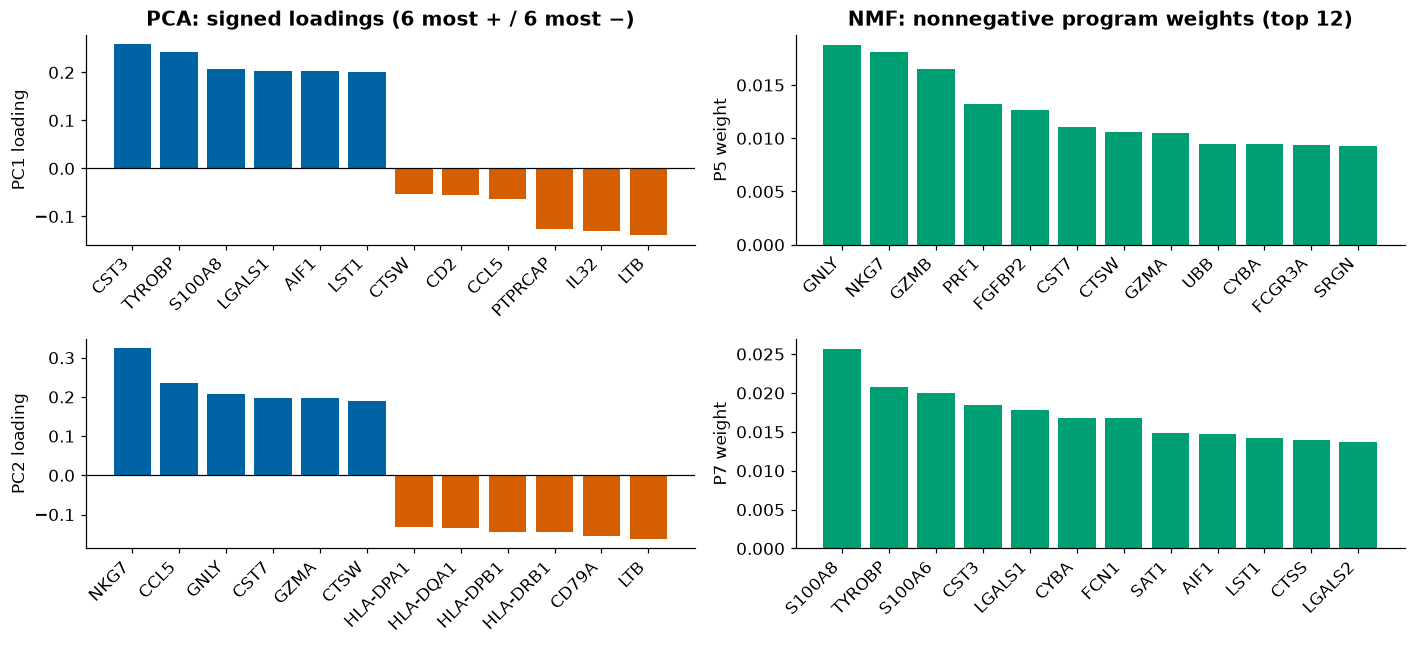

negative entries: PCA loadings (10 PCs) 43%, PCA scores 55%; NMF: 0%
NMF programs: 60% of gene weights are below 1% of the program's largest weight


In [12]:
mu = X.mean(0)
U, s_, Vt = np.linalg.svd(X - mu, full_matrices=False)
Vt = Vt[:K] * np.sign(Vt[:K].sum(1, keepdims=True))
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for r, j in enumerate([0, 1]):
    o_ = np.argsort(Vt[j])
    idx = np.r_[o_[::-1][:6], o_[:6][::-1]]          # 6 most positive, 6 most negative loadings (as on the slide)
    axes[r, 0].bar(range(12), Vt[j, idx], color=[PALETTE[0] if v > 0 else PALETTE[5] for v in Vt[j, idx]])
    axes[r, 0].axhline(0, color="k", lw=0.8)
    axes[r, 0].set_xticks(range(12), genes[idx], rotation=45, ha="right"); axes[r, 0].set_ylabel(f"PC{j + 1} loading")
for r, l in enumerate([l_nk, l_mono]):
    idx = np.argsort(-H[l])[:12]
    axes[r, 1].bar(range(12), H[l, idx], color=PALETTE[2])
    axes[r, 1].set_xticks(range(12), genes[idx], rotation=45, ha="right"); axes[r, 1].set_ylabel(f"{names[l]} weight")
axes[0, 0].set_title("PCA: signed loadings (6 most + / 6 most −)")
axes[0, 1].set_title("NMF: nonnegative program weights (top 12)")
plt.tight_layout(); plt.show()
print(f"negative entries: PCA loadings (10 PCs) {100 * (Vt < 0).mean():.0f}%, PCA scores {100 * ((X - mu) @ Vt.T < 0).mean():.0f}%; NMF: 0%")
thr = 0.01 * H.max(1, keepdims=True)
print(f"NMF programs: {100 * (H < thr).mean():.0f}% of gene weights are below 1% of the program's largest weight")

A PC contrasts two groups of genes (positive vs negative loadings; PC1 puts myeloid genes against lymphoid ones), and a cell's
score is a difference. An NMF program is a list of genes that go *up together*, and a cell's usage is an amount — an
additive, parts-based description. PCA directions are unique and ordered by variance; NMF programs are not.

## 7. Matrix completion: filling in missing expression values

**Dataset.** Bulk tumor RNA-seq (TCGA extract from L02/L15: 801 tumors × 20,531 genes, log scale; UCI ML Repository
"gene expression cancer RNA-Seq", doi:10.24432/C5R88H, CC BY 4.0, from the TCGA Pan-Cancer project, Weinstein et al. 2013).
We keep the 500 most variable genes and split the **entries** at random: 20% **test** (hidden until the end), 10% **validation**,
70% training. We fit

$$\min_{\mathbf W,\mathbf H}\ \sum_{(i,j)\in\Omega}\big(x_{ij} - \mu_j - \mathbf w_i^\top\mathbf h_{:j}\big)^2 + \lambda\big(\|\mathbf W\|_F^2 + \|\mathbf H\|_F^2\big)$$

only on the observed entries $\Omega$ ($\mu_j$ = observed mean of gene $j$, a column bias). **Alternating least squares:**
with $\mathbf H$ fixed, each $\mathbf w_i$ is a small ridge regression on the observed entries of row $i$ — and vice versa.

801 tumors x 500 genes; 20% test, 10% validation entries
gene-mean imputation: validation RMSE 3.66


ALS grid (14 fits, 20 sweeps each): 37 s
validation RMSE (rows: lambda, columns: rank k)
         1     2     3     5     10    20    40
0.1    3.09  2.74  2.39  2.08  1.91  1.86  2.12
100.0  3.09  2.75  2.42  2.14  2.01  1.98  1.98
weak lambda = 0.1 overfits at k = 40: train 1.37, validation 2.12


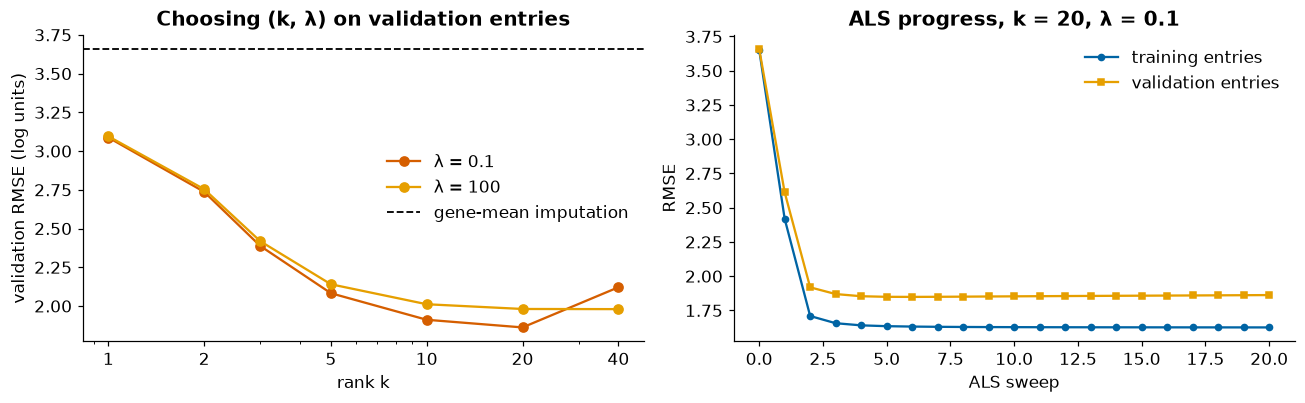

k = 20, lambda = 0.1: after 1 sweep train 2.42 / validation 2.61; after 20 sweeps 1.63 / 1.86


In [13]:
Xt, yt, _ = load_tcga()
Xt = Xt.astype(np.float64)
Xt = Xt[:, np.argsort(-Xt.var(0))[:500]]
u = np.random.default_rng(0).random(Xt.shape)
test, val, train = u < 0.2, (u >= 0.2) & (u < 0.3), u >= 0.3
rmse = lambda Xh, Mask: float(np.sqrt(((Xt - Xh)[Mask] ** 2).mean()))

def als(X, Mask, k, lam, iters=20, seed=0, track=()):
    """ALS on the observed entries Mask, with gene means as column biases. track: masks whose RMSE is recorded per sweep."""
    r = np.random.default_rng(seed)
    n, d = X.shape
    mu = (X * Mask).sum(0) / np.maximum(Mask.sum(0), 1)
    Rm = np.where(Mask, X - mu, 0.0)
    W, H = r.normal(0, 0.1, (n, k)), r.normal(0, 0.1, (k, d))
    I = lam * np.eye(k)
    curve = [[rmse(mu + W @ H, T) for T in track]]
    for _ in range(iters):
        for i in range(n):
            m = Mask[i]; W[i] = np.linalg.solve(H[:, m] @ H[:, m].T + I, H[:, m] @ Rm[i, m])
        for j in range(d):
            m = Mask[:, j]; H[:, j] = np.linalg.solve(W[m].T @ W[m] + I, W[m].T @ Rm[m, j])
        if track:
            curve.append([rmse(mu + W @ H, T) for T in track])
    return mu + W @ H, np.array(curve)

colmean = (Xt * train).sum(0) / train.sum(0)
base_val = rmse(np.broadcast_to(colmean, Xt.shape), val)
print(f"{Xt.shape[0]} tumors x {Xt.shape[1]} genes; {100 * test.mean():.0f}% test, {100 * val.mean():.0f}% validation entries")
print(f"gene-mean imputation: validation RMSE {base_val:.2f}")
t = time.time()
RANKS, LAMS = [1, 2, 3, 5, 10, 20, 40], [0.1, 100.0]
res_val, res_train = np.zeros((2, 7)), np.zeros((2, 7))
for a, lam in enumerate(LAMS):
    for b, k in enumerate(RANKS):
        Xh, curve = als(Xt, train, k, lam, track=(train, val) if (k, lam) == (20, 0.1) else ())
        res_val[a, b], res_train[a, b] = rmse(Xh, val), rmse(Xh, train)
        if (k, lam) == (20, 0.1):
            curve20 = curve
print(f"ALS grid ({len(RANKS) * len(LAMS)} fits, 20 sweeps each): {time.time() - t:.0f} s")
print("validation RMSE (rows: lambda, columns: rank k)")
print(pd.DataFrame(res_val, index=LAMS, columns=RANKS).round(2).to_string())
print(f"weak lambda = 0.1 overfits at k = 40: train {res_train[0, -1]:.2f}, validation {res_val[0, -1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for a, lam in enumerate(LAMS):
    axes[0].plot(RANKS, res_val[a], "o-", color=[PALETTE[5], PALETTE[1]][a], label=f"λ = {lam:g}")
axes[0].axhline(base_val, color="k", ls="--", lw=1.2, label="gene-mean imputation")
axes[0].set_xscale("log"); axes[0].set_xticks([1, 2, 5, 10, 20, 40], ["1", "2", "5", "10", "20", "40"])
axes[0].set(xlabel="rank k", ylabel="validation RMSE (log units)", title="Choosing (k, λ) on validation entries")
axes[0].legend()
axes[1].plot(curve20[:, 0], "o-", color=PALETTE[0], ms=4, label="training entries")
axes[1].plot(curve20[:, 1], "s-", color=PALETTE[1], ms=4, label="validation entries")
axes[1].set(xlabel="ALS sweep", ylabel="RMSE", title="ALS progress, k = 20, λ = 0.1"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"k = 20, lambda = 0.1: after 1 sweep train {curve20[1, 0]:.2f} / validation {curve20[1, 1]:.2f}; "
      f"after 20 sweeps {curve20[-1, 0]:.2f} / {curve20[-1, 1]:.2f}")

Weak regularization overfits at large $k$ (validation error rises again while training error keeps falling); strong
regularization lets a larger rank help. Most of the progress happens in the first few ALS sweeps.
**Evaluation:** choose $(k, \lambda)$ on the validation entries, refit on all observed (train + validation) entries, and
score the untouched test entries once.

In [14]:
a, b = np.unravel_index(res_val.argmin(), res_val.shape)
lam_b, k_b = LAMS[a], RANKS[b]
obs = ~test
Xh, _ = als(Xt, obs, k_b, lam_b)
base_test = rmse(np.broadcast_to((Xt * obs).sum(0) / obs.sum(0), Xt.shape), test)
print(f"chosen k = {k_b}, lambda = {lam_b:g}: test RMSE {rmse(Xh, test):.2f} vs gene-mean imputation {base_test:.2f} "
      f"(SD of hidden values {Xt[test].std():.2f})")

chosen k = 20, lambda = 0.1: test RMSE 1.82 vs gene-mean imputation 3.66 (SD of hidden values 4.18)


**SGD with bias terms** (the recommender-system recipe, Koren et al. 2009): $\hat x_{ij} = \mu + b_i + c_j + \mathbf w_i^\top\mathbf h_{:j}$,
one observed entry at a time. Pure-Python SGD is slow, so we use a 200 × 200 corner of the matrix (same test mask).

SGD, 15 epochs in 7 s: test RMSE 2.10 (gene means: 4.18)


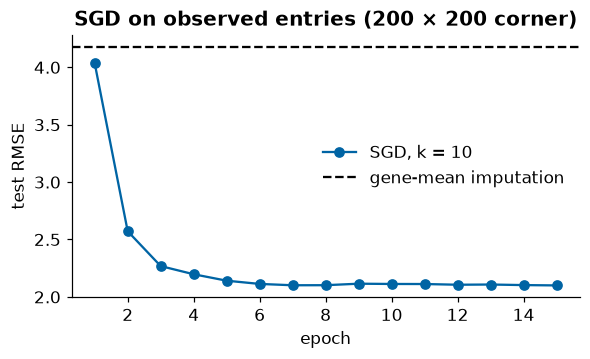

In [15]:
def sgd_mf(X, Mask, k, lam=0.02, lr=0.01, epochs=15, seed=0, eval_mask=None):
    r = np.random.default_rng(seed)
    n, d = X.shape
    ii, jj = np.nonzero(Mask)
    mu = X[Mask].mean(); b = np.zeros(n); c = np.zeros(d)
    W, H = r.normal(0, 0.1, (n, k)), r.normal(0, 0.1, (d, k))
    hist = []
    for ep in range(epochs):
        for t_ in r.permutation(len(ii)):
            i, j = ii[t_], jj[t_]
            e = X[i, j] - (mu + b[i] + c[j] + W[i] @ H[j])
            b[i] += lr * e; c[j] += lr * e
            wi = W[i].copy()                       # both updates use the old w_i
            W[i] += lr * (e * H[j] - lam * W[i]); H[j] += lr * (e * wi - lam * H[j])
        Xh = mu + b[:, None] + c[None, :] + W @ H.T
        hist.append(np.sqrt(((X - Xh)[eval_mask] ** 2).mean()))
    return Xh, hist

Xsub, te_sub = Xt[:200, :200], test[:200, :200]
t = time.time()
_, hist_sgd = sgd_mf(Xsub, ~te_sub, k=10, eval_mask=te_sub)
base_sub = np.sqrt(((Xsub - (Xsub * ~te_sub).sum(0) / (~te_sub).sum(0))[te_sub] ** 2).mean())
print(f"SGD, {len(hist_sgd)} epochs in {time.time() - t:.0f} s: test RMSE {hist_sgd[-1]:.2f} (gene means: {base_sub:.2f})")
plt.figure(figsize=(5.5, 3.4)); plt.plot(range(1, len(hist_sgd) + 1), hist_sgd, "o-", color=PALETTE[0], label="SGD, k = 10")
plt.axhline(base_sub, ls="--", color="k", label="gene-mean imputation")
plt.xlabel("epoch"); plt.ylabel("test RMSE"); plt.title("SGD on observed entries (200 × 200 corner)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. (CS284A) NMF with the KL / Poisson loss on counts

For count data, maximizing a Poisson likelihood $x_{ij}\sim\mathrm{Poisson}((\mathbf W\mathbf H)_{ij})$ is the same as minimizing the
generalized KL divergence $\sum_{ij} x_{ij}\log\frac{x_{ij}}{(\mathbf W\mathbf H)_{ij}} - x_{ij} + (\mathbf W\mathbf H)_{ij}$.
scikit-learn: `beta_loss="kullback-leibler"` with `solver="mu"`. We fit it to raw UMI counts of the same genes.

In [16]:
Craw = np.asarray(adata[:, hv.var_names].layers["counts"].todense(), dtype=np.float64)
t = time.time()
mk = NMF(K, init="nndsvda", solver="mu", beta_loss="kullback-leibler", max_iter=300, tol=1e-4, random_state=0)
Wk = mk.fit_transform(Craw)
Hk = mk.components_
print(f"KL-NMF on {Craw.shape} counts: {time.time() - t:.0f} s")
for l in range(K):
    use = Wk[:, l] * Hk[l].sum()
    best_ct = pd.Series(use).groupby(ctype).mean().idxmax()
    print(f"program {l + 1:2d} (most used by {best_ct:12s}):", ", ".join(genes[np.argsort(-Hk[l])[:8]]))

KL-NMF on (2638, 1838) counts: 10 s
program  1 (most used by FCGR3A mono ): CST3, COTL1, LST1, TYROBP, AIF1, SAT1, FCER1G, S100A6
program  2 (most used by NK          ): NKG7, GNLY, GZMB, PRF1, CST7, FGFBP2, CTSW, CYBA
program  3 (most used by DC          ): HLA-DPB1, HLA-DPA1, HLA-DRB1, CD37, HLA-DQA1, CD79A, LTB, HLA-DQB1
program  4 (most used by CD4 T       ): LTB, IL32, UBB, HINT1, PTPRCAP, SRSF5, S100A6, GIMAP7
program  5 (most used by CD14 mono   ): S100A8, TYROBP, S100A6, CST3, LGALS1, FCN1, LGALS2, GPX1
program  6 (most used by CD8 T       ): CCL5, IL32, NKG7, GZMK, PTPRCAP, GZMA, CYBA, LYAR
program  7 (most used by B           ): KIF5B, CD37, C10orf32, DNAJC15, GABARAPL2, CLEC2B, SMDT1, CYBA
program  8 (most used by Platelet    ): PPBP, GPX1, PF4, TALDO1, HIST1H2AC, SDPR, FERMT3, GNG11
program  9 (most used by DC          ): LIMD2, SF3B5, SRGN, CYBA, IGJ, ARPC1B, TRAF3IP3, UBE2D2
program 10 (most used by CD4 T       ): SRSF5, ATP5D, ATP5A1, SDHB, TRAF3IP3, CD48, GGNBP2, SELL


## 9. (CS284A) Mutational signatures: recover planted signatures from simulated catalogs

A tumor's single-base substitutions are counted in **96 channels**: 6 substitution classes (C>A, C>G, C>T, T>A, T>C, T>G, the
mutated base written as the pyrimidine of the pair) × 4 possible 5′ neighbors × 4 possible 3′ neighbors. A catalog matrix
(tumors × 96) is factorized as exposures × signatures (Alexandrov et al., *Nature* 2013). Here the three signatures are
**made up** (qualitative shapes only; they are not COSMIC signatures): C>T at CpG, mostly C>A, and C>T after a pyrimidine.

120 simulated tumors, median 200 mutations per tumor
cosine similarity of recovered vs planted signatures (sorted): [0.995 0.995 1.   ]


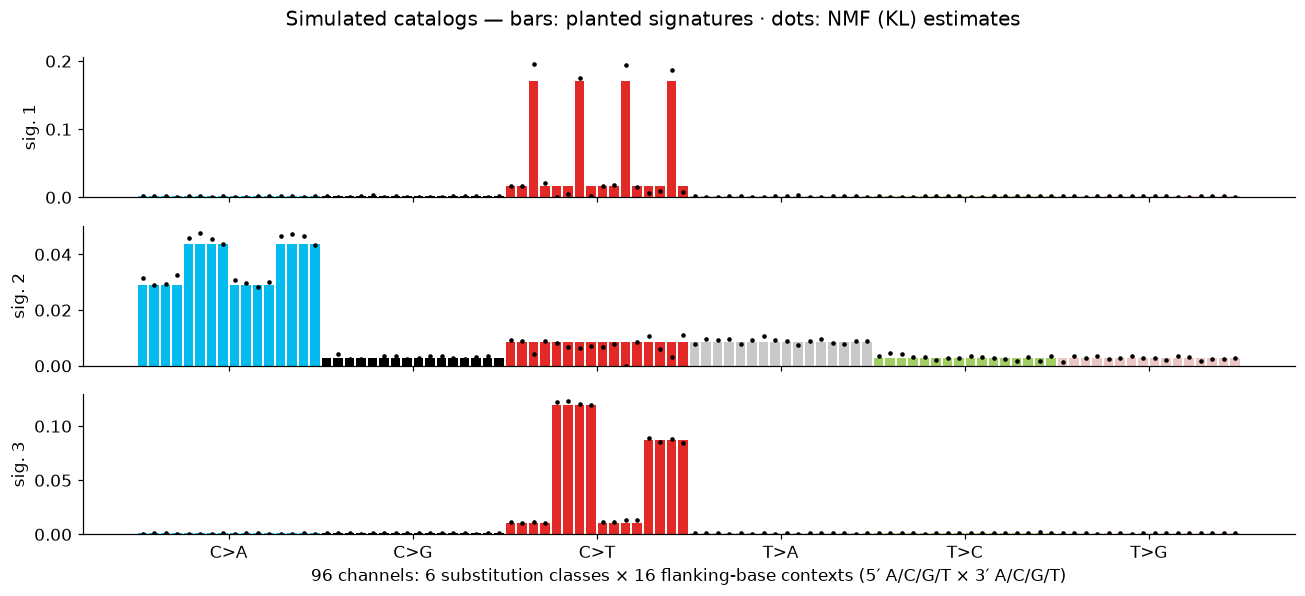

In [17]:
SUBS = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
ch = [(s, a + s[0] + b) for s in SUBS for a in "ACGT" for b in "ACGT"]   # (class, 5' base + ref + 3' base)
S1 = np.array([6.0 if (s == "C>T" and c[2] == "G") else (0.6 if s == "C>T" else 0.05) for s, c in ch])
S2 = np.array([2.0 + (c[0] in "CT") if s == "C>A" else (0.6 if s in ("C>T", "T>A") else 0.2) for s, c in ch])
S3 = np.array([(5.5 if c[0] == "C" else 4.0) if (s == "C>T" and c[0] in "CT") else (0.5 if s == "C>T" else 0.05) for s, c in ch])
Sig = np.vstack([S1, S2, S3]); Sig /= Sig.sum(1, keepdims=True)
r = np.random.default_rng(0)
E = r.gamma(0.6, 1.0, (120, 3)) * r.choice([50, 200, 800], (120, 1))    # exposures (mutations per signature)
catalog = r.poisson(E @ Sig).astype(float)
m = NMF(3, init="nndsvda", solver="mu", beta_loss="kullback-leibler", max_iter=3000, tol=1e-6, random_state=0)
Ehat = m.fit_transform(catalog); Shat = m.components_ / m.components_.sum(1, keepdims=True)
C = (Shat / np.linalg.norm(Shat, axis=1, keepdims=True)) @ (Sig / np.linalg.norm(Sig, axis=1, keepdims=True)).T
ri, ci = linear_sum_assignment(-C)
print(f"{len(catalog)} simulated tumors, median {np.median(catalog.sum(1)):.0f} mutations per tumor")
print("cosine similarity of recovered vs planted signatures (sorted):", np.round(np.sort(C[ri, ci]), 3))
cols = np.repeat(["#03BCEE", "#010101", "#E32926", "#CAC9C9", "#A1CE63", "#EBC6C4"], 16)
fig, axes = plt.subplots(3, 1, figsize=(12, 5.5), sharex=True)
for j, ax in enumerate(axes):
    ax.bar(range(96), Sig[j], color=cols); ax.plot(range(96), Shat[ri[list(ci).index(j)]], "k.", ms=4)
    ax.set_ylabel(f"sig. {j + 1}")
axes[-1].set_xticks(np.arange(6) * 16 + 7.5, SUBS)
axes[-1].set_xlabel("96 channels: 6 substitution classes × 16 flanking-base contexts (5′ A/C/G/T × 3′ A/C/G/T)")
plt.suptitle("Simulated catalogs — bars: planted signatures · dots: NMF (KL) estimates"); plt.tight_layout(); plt.show()

## 10. Biological interpretation

- **Programs, not clusters.** NMF describes each cell as an additive mix of gene programs. PBMC3k programs line up with
  known biology — cytotoxic granules (GNLY, NKG7, GZMB, PRF1) in NK cells, CD79A/MS4A1 plus MHC class II in B cells,
  S100A8/FCN1 in CD14 monocytes, PPBP/PF4 in platelets — and some are **shared** across cell types (an HLA class II
  antigen-presentation program used by DCs, monocytes and B cells). A cell using two programs may run an identity plus an
  activity program, be in transition, or be a technical artifact (doublet, ambient RNA): check before interpreting.
- **Choose k with care.** Reconstruction error falls with every extra program; programs reproduced across restarts
  (stability) and interpretable top genes are what justify a choice. Name programs by top genes, and never compare
  "program 3" across runs without matching.
- **Low rank predicts missing values.** On TCGA tumors a rank-20 model predicts hidden expression values with half the
  error of gene means, because co-regulated genes share factors. Random masking is the easy case; whole missing genes or
  samples (Try it 2) are much harder.
- **Mutational signatures** are the same model on counts: exposures × signatures, with a Poisson/KL loss. The signatures
  here are simulated; real analyses match estimates to the COSMIC catalog. No clinical conclusions from this notebook.

In [18]:
print(f"total runtime: {time.time() - T0:.0f} s")

total runtime: 213 s


## Try it yourself

1. **k = 6 vs k = 14: which programs split?** Set `K = 6` (then `K = 14`) in Section 3 and rerun Sections 3–4.
   Which programs split or merge? Does the NK program survive?
2. **Hide whole genes, not random entries.** In Section 7, hide a block — a random 10% of the genes in 10% of the tumors
   (as if those genes were not on one platform's panel):
   `blk = np.zeros(Xt.shape, bool); blk[np.ix_(rng.random(801) < 0.1, rng.random(500) < 0.1)] = True`, then
   `test = blk; val = ~blk & (u < 0.1); train = ~blk & (u >= 0.1)`. Is imputation still better than the gene mean?
   What happens if a gene is hidden in *all* tumors, and why is that the hard case?
3. **Center X before NMF: what breaks?** Try `NMF(10).fit(X - X.mean(0))`, then clip negatives to 0
   (`np.clip(X - X.mean(0), 0, None)`). What happens to the programs, and why is centering incompatible with NMF?
4. Replace the input by genes scaled to unit variance *without centering* (`X / X.std(0)`, as cNMF does). Do rare
   cell types (e.g., dendritic cells, platelets) get their own programs?
5. Reproduce the slide's $k$ figure: `KS_SWEEP = range(2, 17)`, `N_SWEEP = 10` in Section 5 (≈ 15–25 min on a CPU).
6. (CS284A) Implement the KL multiplicative updates yourself and check that the Poisson log-likelihood increases every iteration.